In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('train.csv')
df

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.00
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.00
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.00
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.00
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21258,4,106.957877,53.095769,82.515384,43.135565,1.177145,1.254119,146.88130,15.504479,65.764081,...,3.555556,3.223710,3.519911,1.377820,0.913658,1,2.168889,0.433013,0.496904,2.44
21259,5,92.266740,49.021367,64.812662,32.867748,1.323287,1.571630,188.38390,7.353333,69.232655,...,2.047619,2.168944,2.038991,1.594167,1.337246,1,0.904762,0.400000,0.212959,122.10
21260,2,99.663190,95.609104,99.433882,95.464320,0.690847,0.530198,13.51362,53.041104,6.756810,...,4.800000,4.472136,4.781762,0.686962,0.450561,1,3.200000,0.500000,0.400000,1.98
21261,2,99.663190,97.095602,99.433882,96.901083,0.690847,0.640883,13.51362,31.115202,6.756810,...,4.690000,4.472136,4.665819,0.686962,0.577601,1,2.210000,0.500000,0.462493,1.84


### Seccion 3. Analsis de datos cuantitativos.

In [3]:
print(f"N° Registros: {df.shape[0]}")
print(f"N° Columnas: {df.shape[1]}")

nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
cantidad_nulos = nulos.shape[0]
print(f"Columnas con elementos nulos: ")
print(nulos.to_string())
print(f"Cantidad de columnas nulas: {cantidad_nulos}")


N° Registros: 21263
N° Columnas: 82
Columnas con elementos nulos: 
Series([], )
Cantidad de columnas nulas: 0


In [4]:
matriz_corr = df.corr()
relevantes = matriz_corr["critical_temp"] >= 0.5
matriz_corr_filtr = matriz_corr.loc[relevantes, relevantes]
columnas_relevantes = matriz_corr_filtr.columns.tolist() ## estudiar


### Grafico de correlaciones

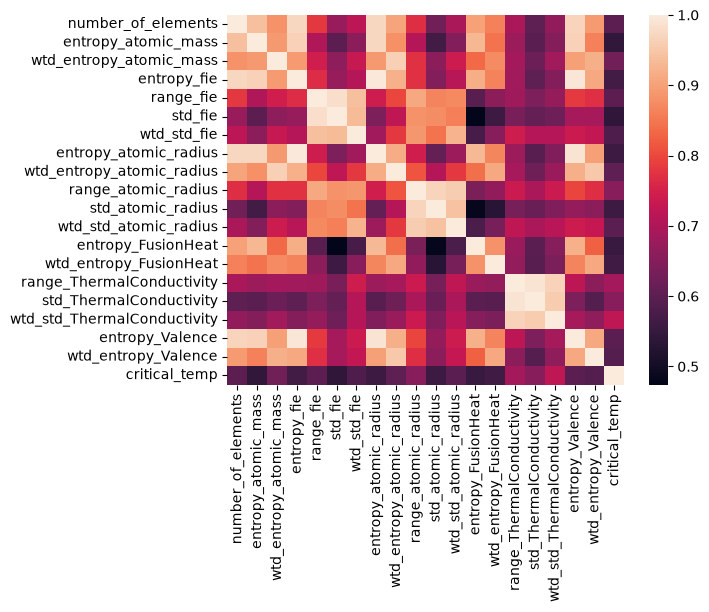

In [5]:
sns.heatmap(matriz_corr_filtr, annot=False)
plt.show()

### Resumen estadistico.

In [6]:
df_filtrado = df[columnas_relevantes]
print("Resumen estadistico")
resumen = df_filtrado.describe()

curtosis = df_filtrado.kurtosis().to_frame().T
resumen.loc['kurt'] = curtosis.loc[0]

asimetria = df_filtrado.skew().to_frame().T
resumen.loc['skew'] = asimetria.loc[0]

print(resumen.to_string())

Resumen estadistico
       number_of_elements  entropy_atomic_mass  wtd_entropy_atomic_mass   entropy_fie     range_fie       std_fie   wtd_std_fie  entropy_atomic_radius  wtd_entropy_atomic_radius  range_atomic_radius  std_atomic_radius  wtd_std_atomic_radius  entropy_FusionHeat  wtd_entropy_FusionHeat  range_ThermalConductivity  std_ThermalConductivity  wtd_std_ThermalConductivity  entropy_Valence  wtd_entropy_Valence  critical_temp
count        21263.000000         21263.000000             21263.000000  21263.000000  21263.000000  21263.000000  21263.000000           21263.000000               21263.000000         21263.000000       21263.000000           21263.000000        21263.000000            21263.000000               21263.000000             21263.000000                 21263.000000     21263.000000         21263.000000   21263.000000
mean             4.115224             1.165608                 1.063884      1.299172    572.222612    215.631279    224.050033               

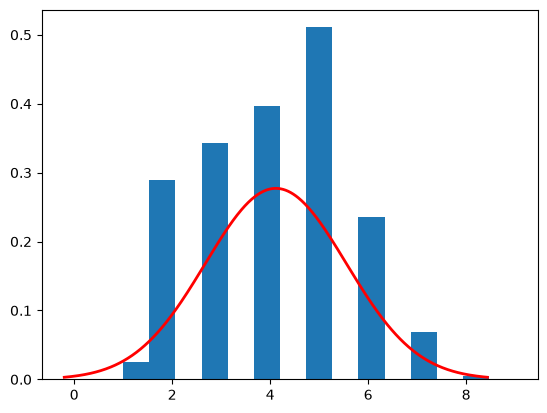

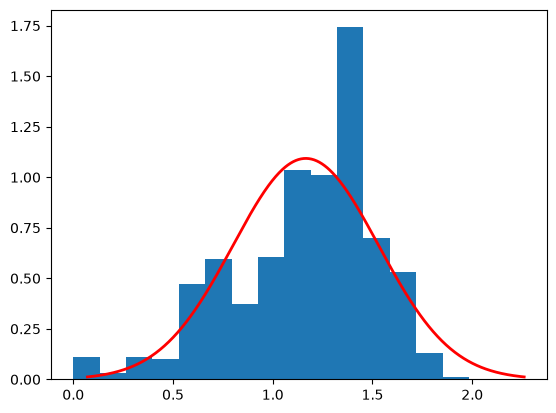

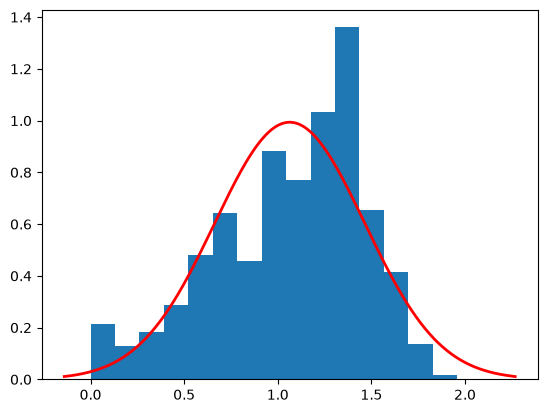

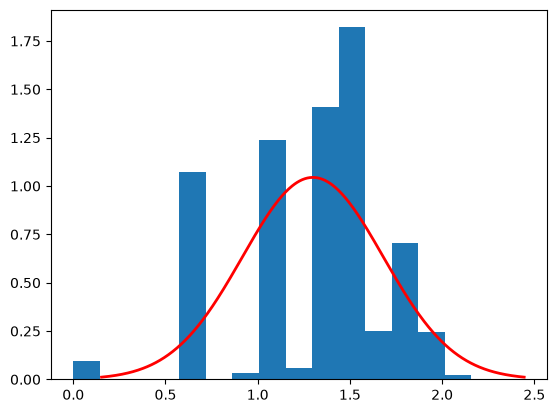

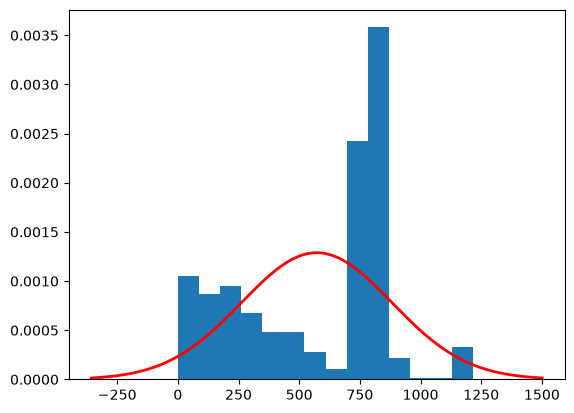

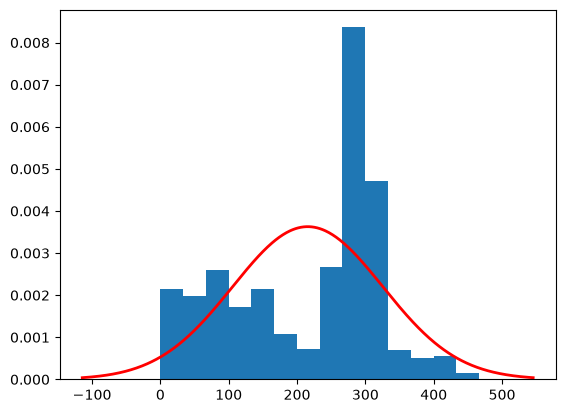

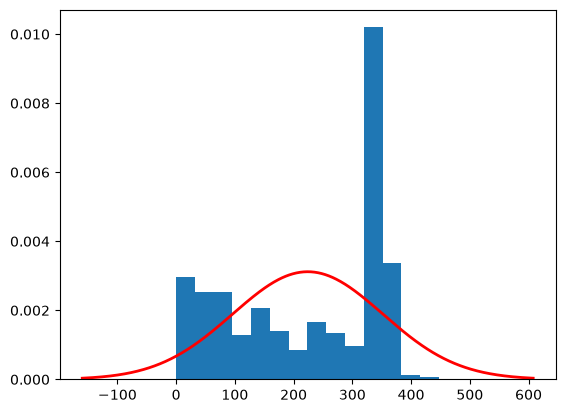

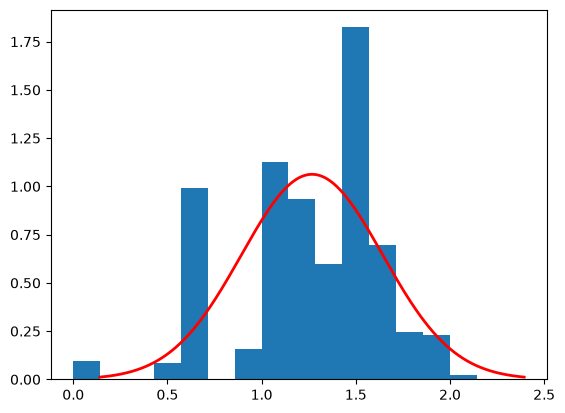

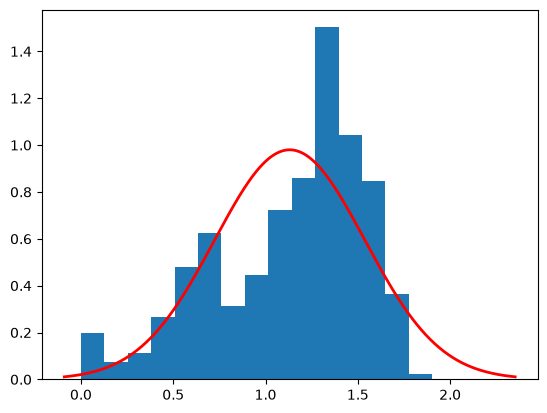

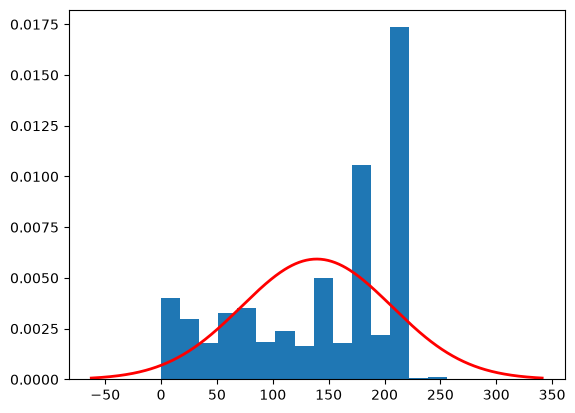

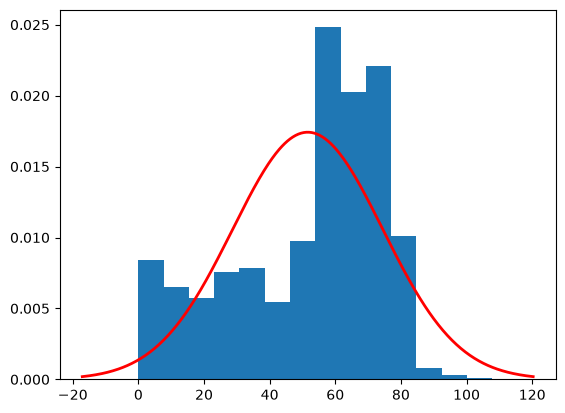

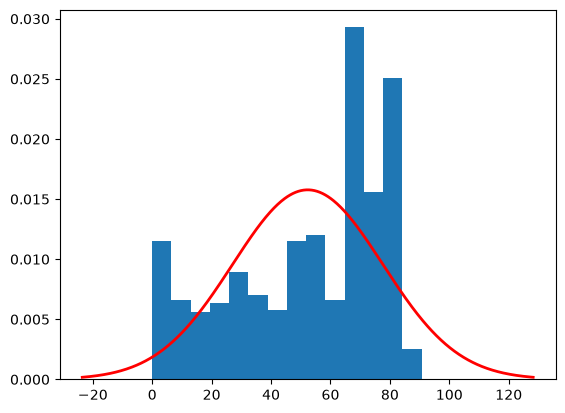

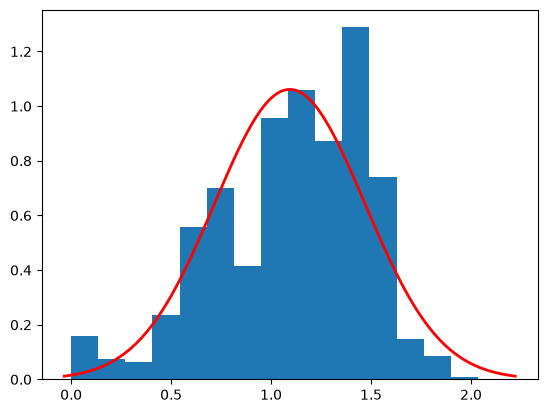

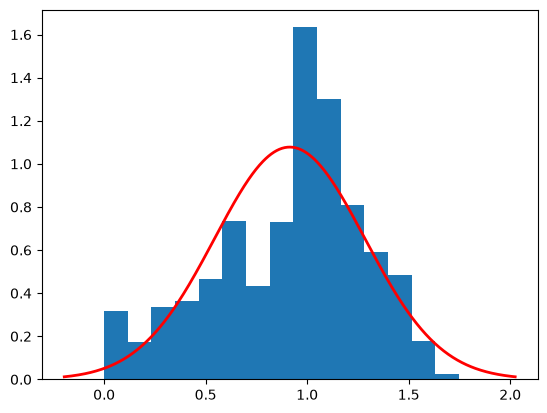

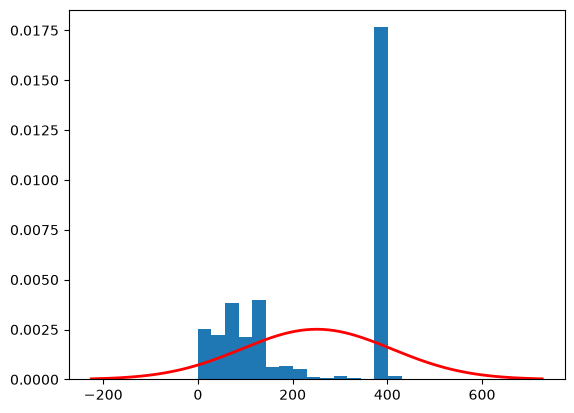

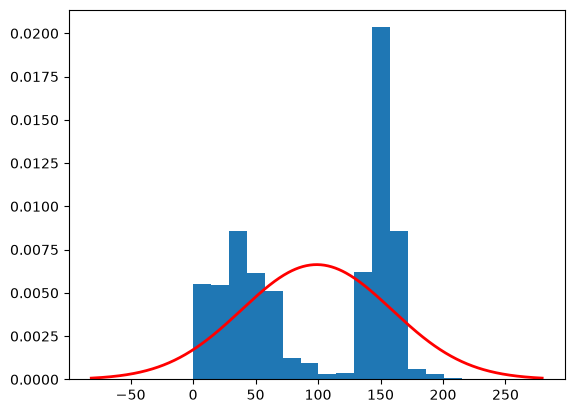

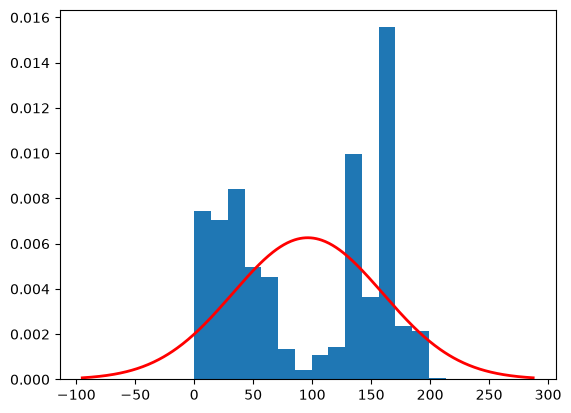

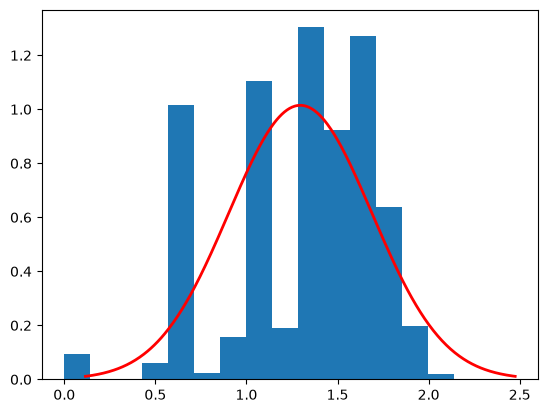

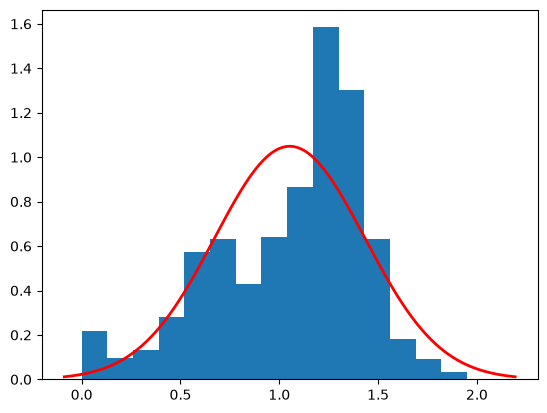

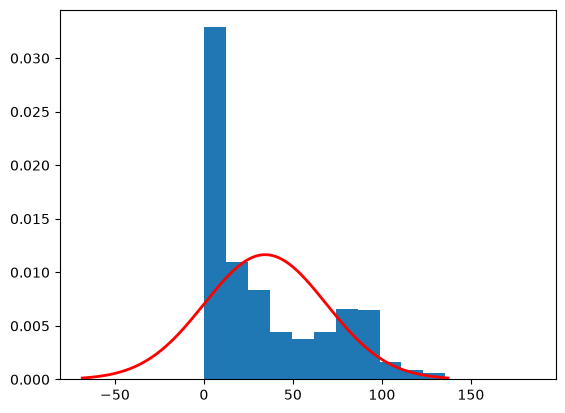

In [7]:
for columna in columnas_relevantes:
    x = df_filtrado[columna]
    k = int(1 + 3.322 * np.log10(df_filtrado.shape[0]))

    media = df_filtrado[columna].mean()
    std = df_filtrado[columna].std()

    curva_x = np.linspace(media - 3 * std, media + 3 * std, 500)
    curva_y = stats.norm.pdf(curva_x, loc=media, scale=std)

    plt.hist(x, bins=k, density=True)
    plt.plot(curva_x, curva_y, color='red', linewidth=2)
    plt.xlabel
    plt.show()

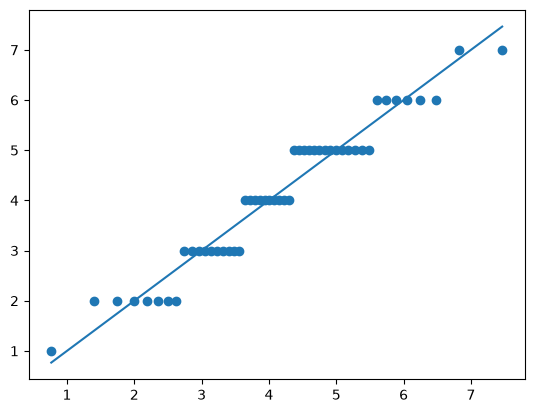

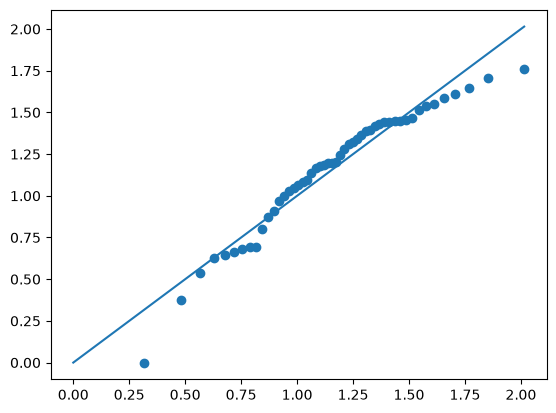

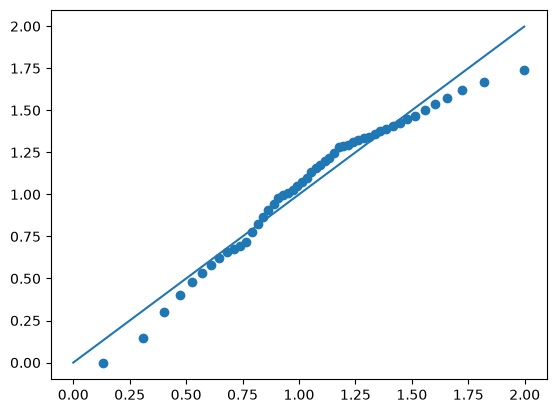

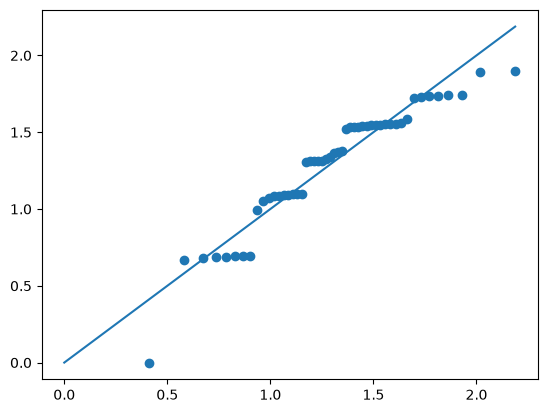

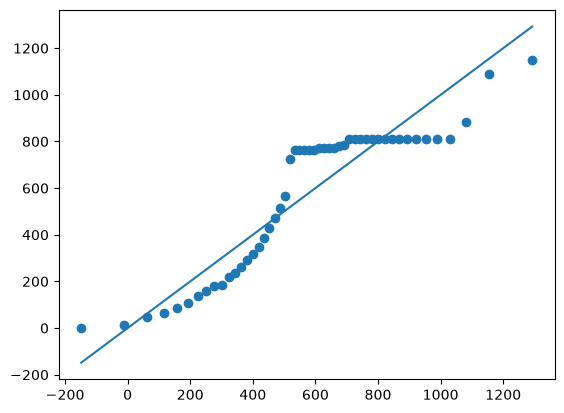

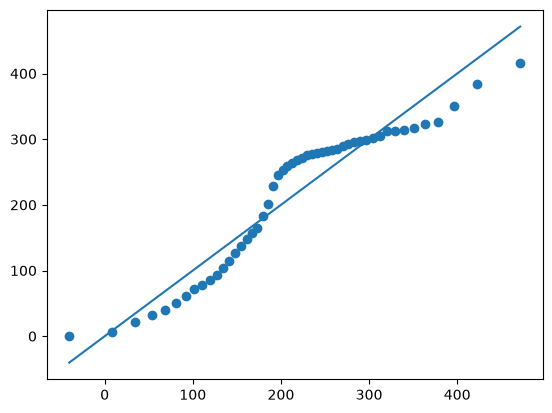

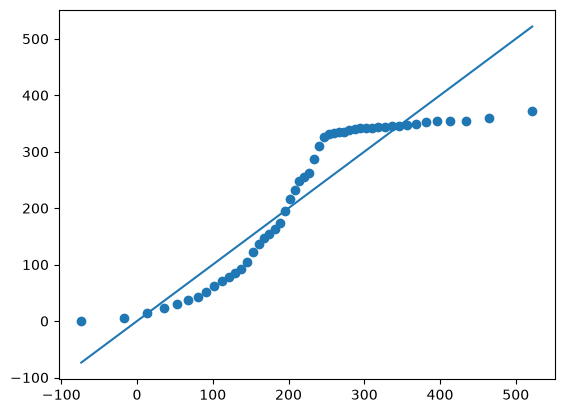

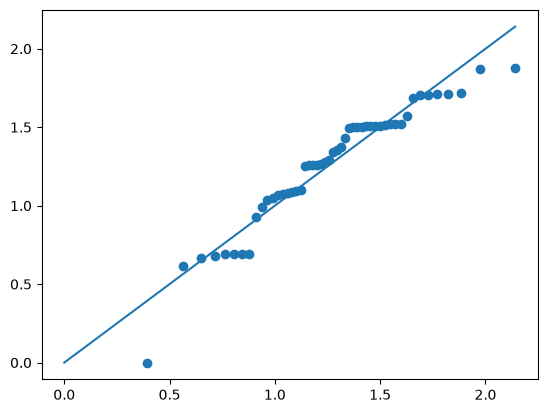

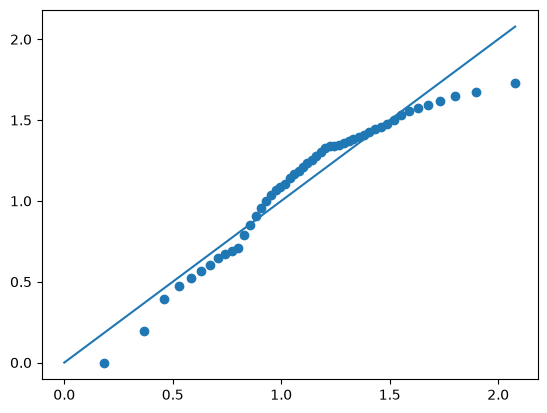

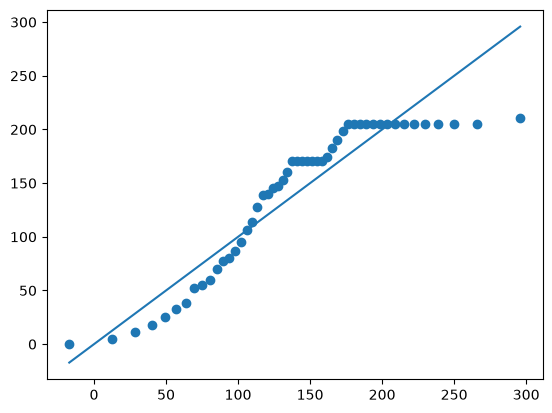

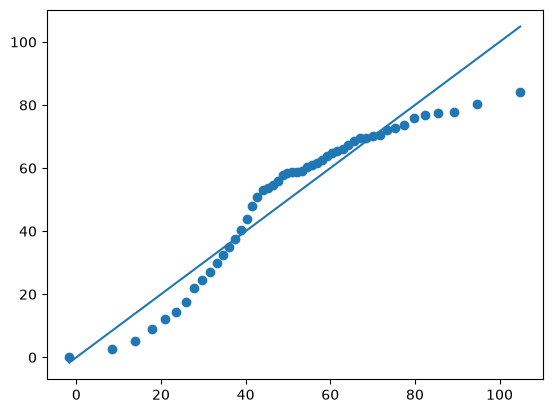

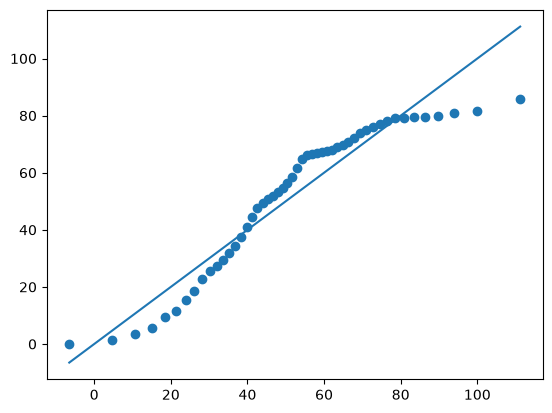

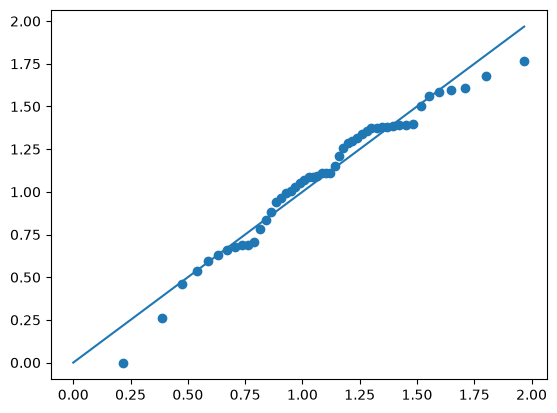

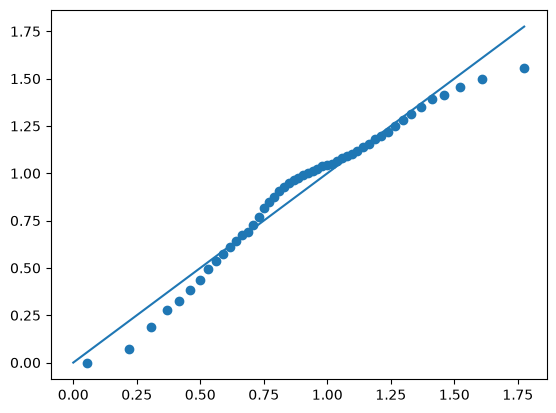

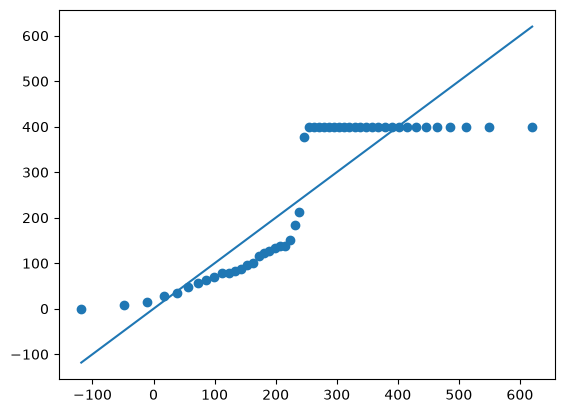

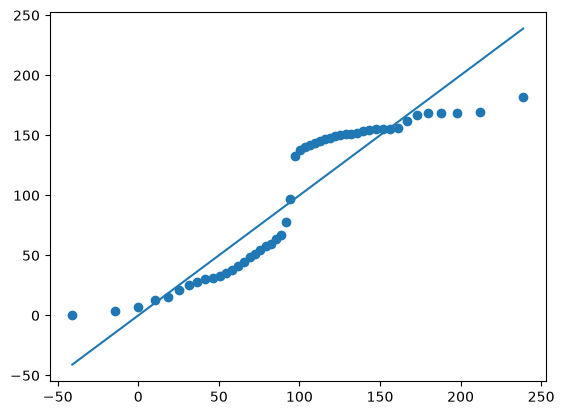

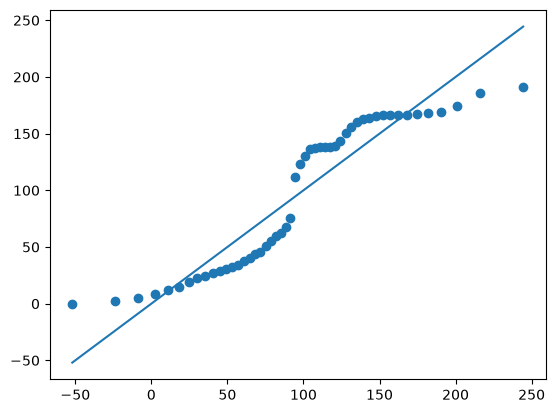

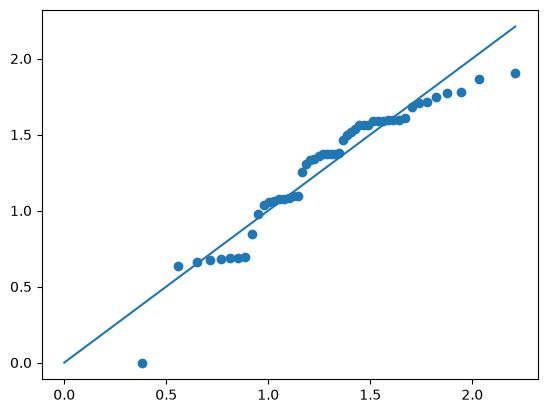

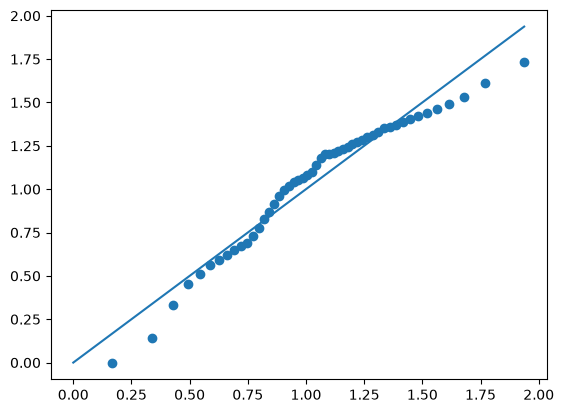

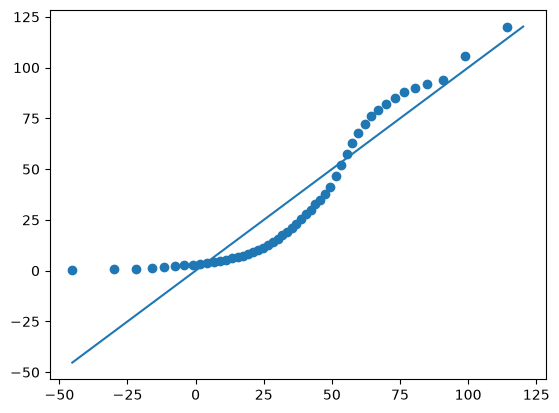

In [10]:
## grafico q-q
percentiles = [i/100 for i in range(1, 101, 2)]

for columna in columnas_relevantes:

    media = df_filtrado[columna].mean()
    std = df_filtrado[columna].std()

    percentil_teorico = stats.norm.ppf(percentiles, loc=media, scale=std)
    percentil_real = df_filtrado[columna].quantile(percentiles)

    min_val = min(np.min(percentil_teorico), np.min(percentil_real))
    max_val = max(np.max(percentil_teorico), np.max(percentil_real))

    linea = np.linspace(min_val, max_val, 10)

    plt.scatter(percentil_teorico, percentil_real)
    plt.plot(linea, linea)
    plt.show()

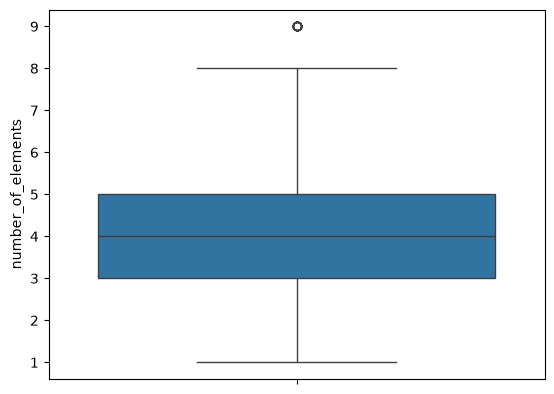

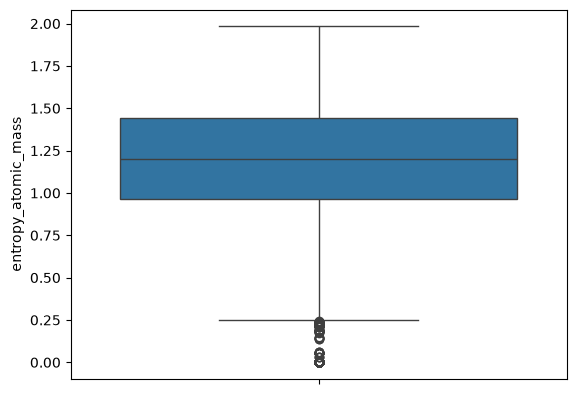

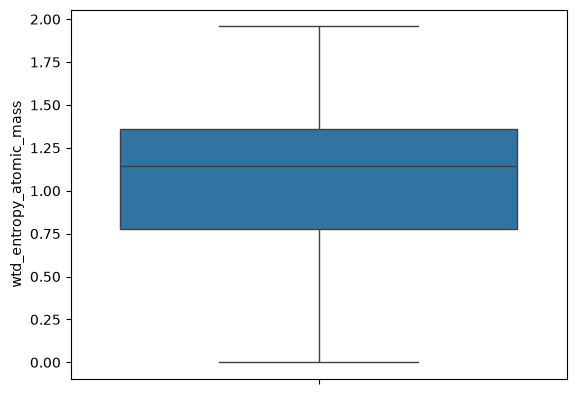

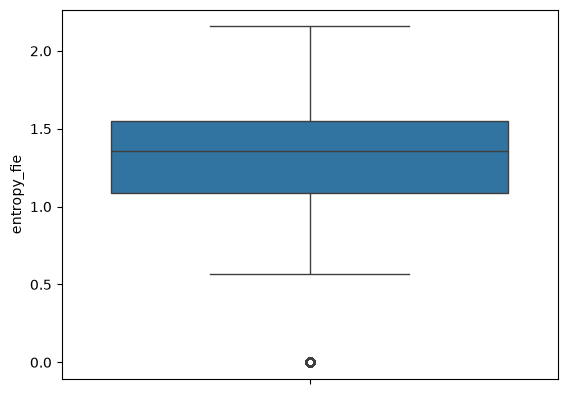

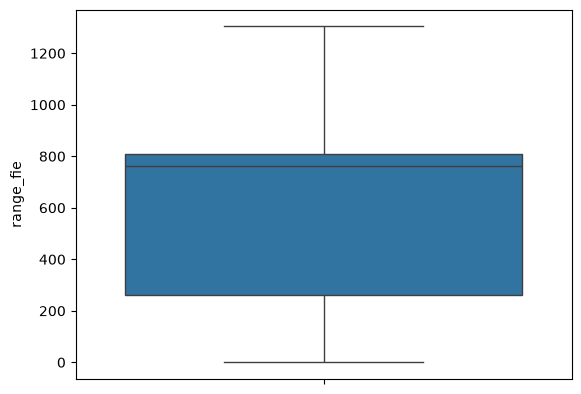

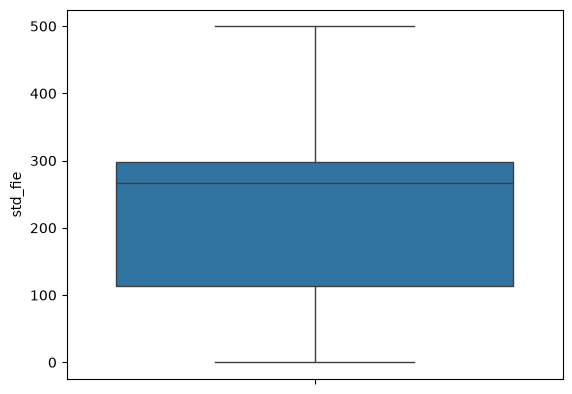

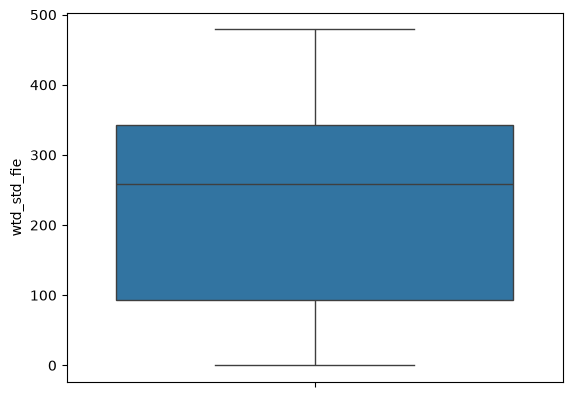

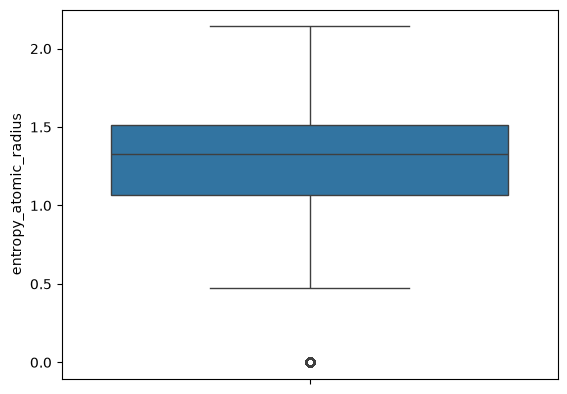

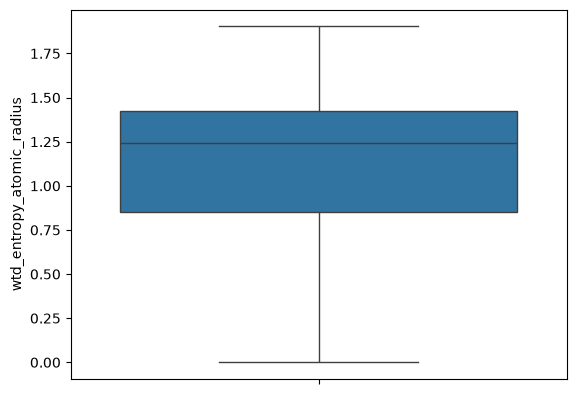

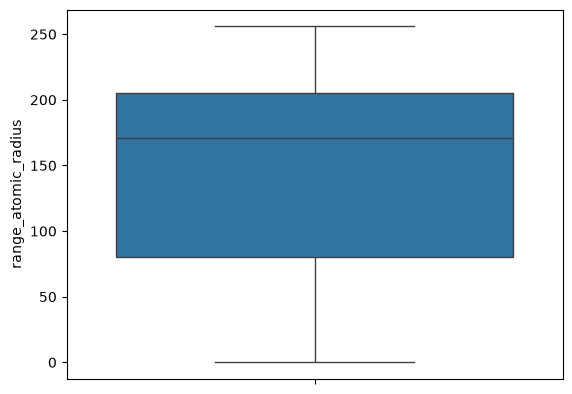

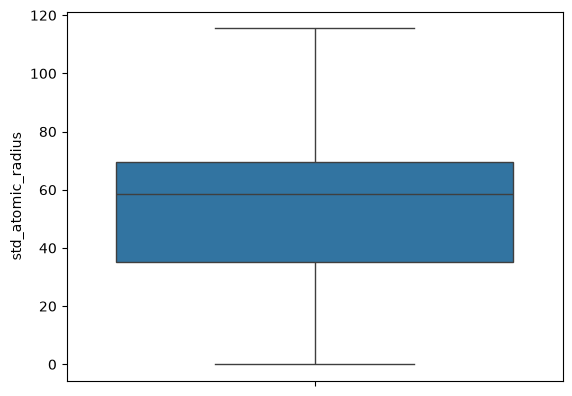

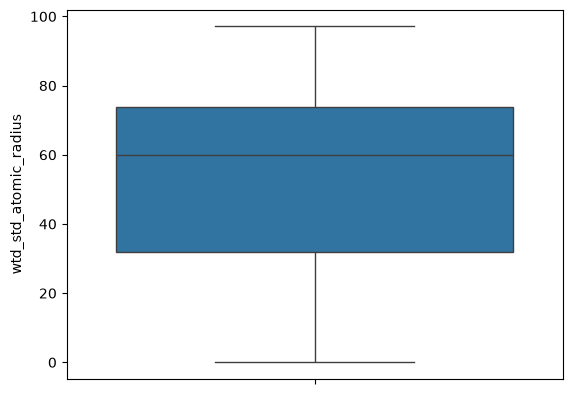

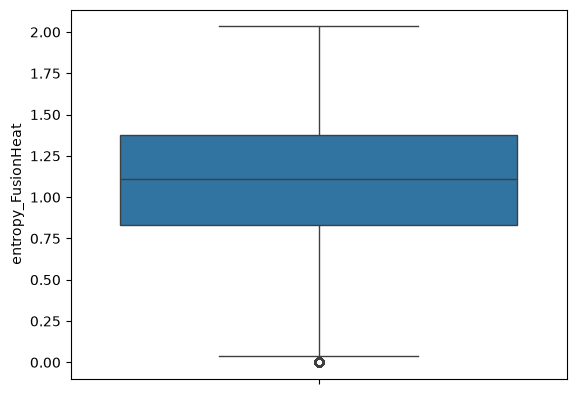

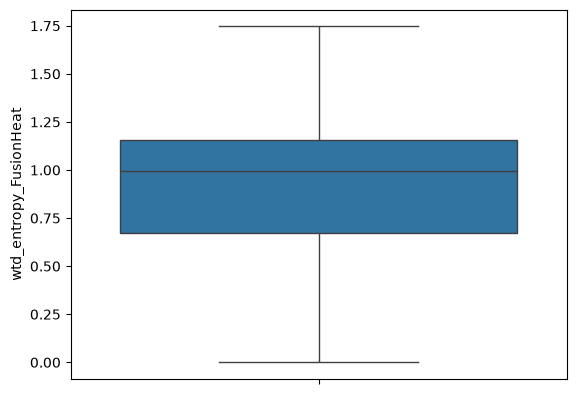

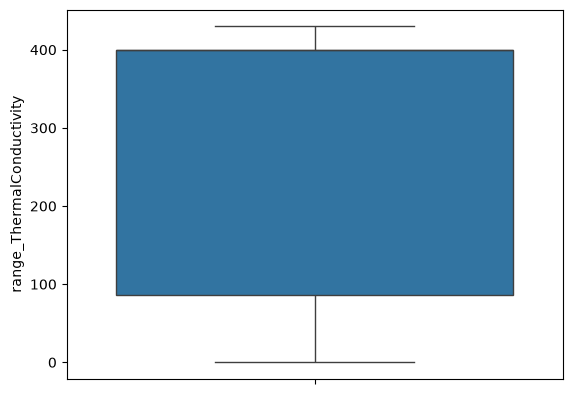

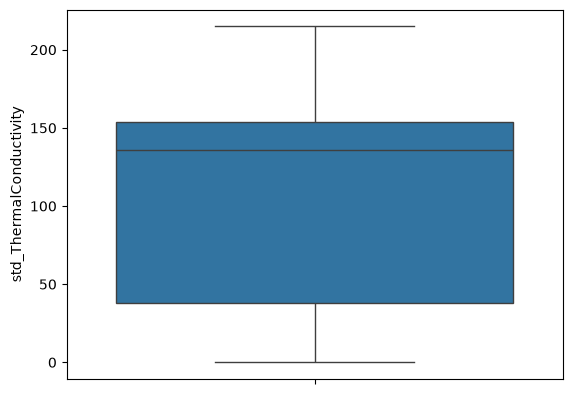

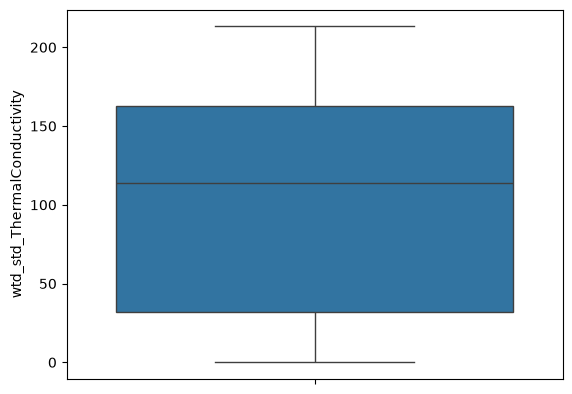

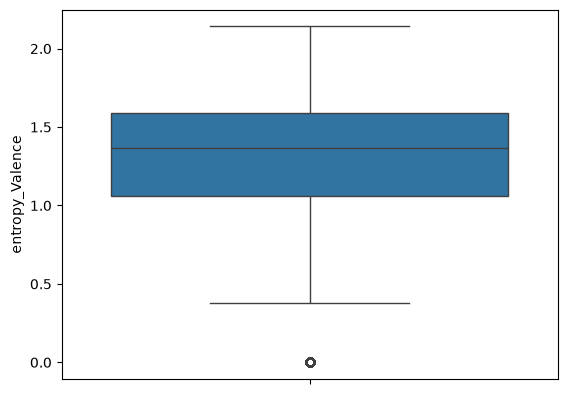

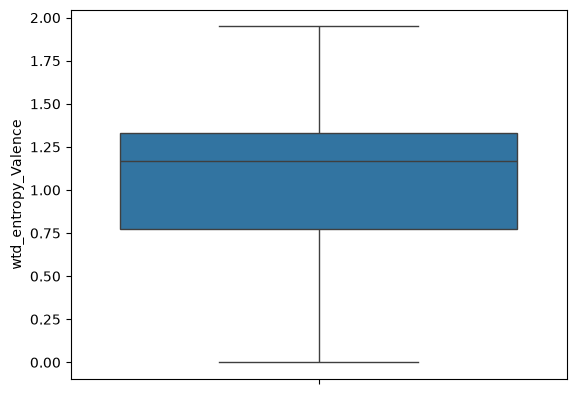

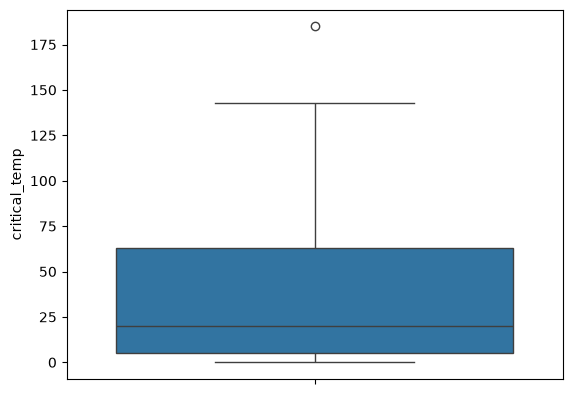

In [8]:
for i in columnas_relevantes:
    sns.boxplot(df[i])
    plt.show()

In [9]:
# pruebas de bondad

# recibe la columna q quiere comaprar, con la curva acumulada q se compara
# H0 la columna tiene distribucion normal
# H1 la columna no tiene distribucion normal

alpha = 0.05

for columna in columnas_relevantes:

    D, p = stats.kstest(df_filtrado[columna], stats.norm(loc=media, scale=std).cdf)
    if p < alpha:
        print(f"H0 se rechaza: {columna} no tiene distribucion normal")
    else:
        print(f"H0 se acepta: {columna}: tiene distribucion normal")


H0 se rechaza: number_of_elements no tiene distribucion normal
H0 se rechaza: entropy_atomic_mass no tiene distribucion normal
H0 se rechaza: wtd_entropy_atomic_mass no tiene distribucion normal
H0 se rechaza: entropy_fie no tiene distribucion normal
H0 se rechaza: range_fie no tiene distribucion normal
H0 se rechaza: std_fie no tiene distribucion normal
H0 se rechaza: wtd_std_fie no tiene distribucion normal
H0 se rechaza: entropy_atomic_radius no tiene distribucion normal
H0 se rechaza: wtd_entropy_atomic_radius no tiene distribucion normal
H0 se rechaza: range_atomic_radius no tiene distribucion normal
H0 se rechaza: std_atomic_radius no tiene distribucion normal
H0 se rechaza: wtd_std_atomic_radius no tiene distribucion normal
H0 se rechaza: entropy_FusionHeat no tiene distribucion normal
H0 se rechaza: wtd_entropy_FusionHeat no tiene distribucion normal
H0 se rechaza: range_ThermalConductivity no tiene distribucion normal
H0 se rechaza: std_ThermalConductivity no tiene distribucio

el analisi de normalida continene un muestra considerabla para que sea represetnativa n= 21000

sin datos nulo lo q elimina esl sesgo por elminacion

que lo materiales analizaos sea supercondicutores implica una lmitacion o sesgo, pues se ignora el comportminto de matariales no conocdios.

### LIMPIEZA

para el tratmiento de volres atipicos se elminara las filas las cuales contengan el menos un 37,5% de valores atipicos. Dado que cada fila contiene 10 medidas estadisticas para 8 propiedades disntias, eso implica que muchas columasn estan relacioanda entre si, por tanto un outlier en una de ellas puede signicar un outlier de cualquier otra medida de esa propiedad, para amortiguar ese sesgo se utlizara como valor repsetantivo de cada propieda la media ponderara: wtd_mean; si una fila posee 3 valores contamidso indica que aproximadamente tiene 3 propiedades completas contaminadas. esto no es una represantion exacta de la realida, mas bien una aproximacion estadistica.

In [10]:
columnas = df.columns

dic_outliers = dict.fromkeys(columnas)


for columna in columnas:
    q1 = np.quantile(df[columna], 0.25)
    q3 = np.quantile(df[columna], 0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    outliers_columna = (df[columna])[mascara]
    dic_outliers[columna] = outliers_columna

# seleciona rsolo las columans wtd_mean
df_outliers = pd.DataFrame(dic_outliers)
wtd_mean = df.filter(like='wtd_mean').columns
df_outliers["n_atipicos"] = df_outliers[wtd_mean].notna().sum(axis=1)

df["n_atipicos"] = df_outliers["n_atipicos"]
df.loc[df['n_atipicos'].isna(), 'n_atipicos'] = 0
df_filtrados = df[df['n_atipicos'] < 3]
df_filtrados = df_filtrados.reset_index(drop=True)
df_filtrados = df_filtrados.drop(columns=['n_atipicos'])

In [11]:
columnas = df_filtrados.columns

medias = df_filtrados[columnas].mean()
stds = df_filtrados[columnas].std()

df_filtrados[columnas] = (df_filtrados[columnas] - medias) / stds
df_filtrados

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,-0.092950,0.069089,-0.442009,-0.141285,-0.608990,0.031505,-0.020391,0.126857,-0.029254,0.375219,...,-0.748067,-0.803196,-0.707312,0.173917,0.019169,-0.842422,-0.402624,-0.842222,-0.524520,-0.166568
1,0.605449,0.199836,-0.421623,0.083829,-0.601035,0.770960,-0.032104,0.126857,0.142934,0.130559,...,-0.748067,-1.118047,-0.715176,0.657406,-0.031449,-0.037248,-0.357434,-0.429990,-0.455224,-0.254110
2,-0.092950,0.069089,-0.441308,-0.141285,-0.608822,0.031505,-0.238521,0.126857,0.126341,0.375219,...,-0.735912,-0.803196,-0.696174,0.173917,-0.079529,-0.842422,-0.372498,-0.842222,-0.507743,-0.458375
3,-0.092950,0.069089,-0.441658,-0.141285,-0.608906,0.031505,-0.121623,0.126857,0.048543,0.375219,...,-0.741990,-0.803196,-0.701751,0.173917,-0.027152,-0.842422,-0.387561,-0.842222,-0.515969,-0.370833
4,-0.092950,0.069089,-0.442710,-0.141285,-0.609157,0.031505,0.148297,0.126857,-0.184848,0.375219,...,-0.760223,-0.803196,-0.718386,0.173917,0.098645,-0.842422,-0.432750,-0.842222,-0.542641,-0.341652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21071,-0.092950,0.691375,-0.590206,0.395761,-0.409564,0.018650,0.463559,0.567543,-0.671571,1.067670,...,0.356715,0.175030,0.415689,0.196775,-0.387288,-0.842422,0.739491,-0.842222,-0.393066,-0.941607
21072,0.605449,0.183859,-0.716874,-0.192781,-0.701298,0.422612,1.265024,1.330397,-0.992963,1.241775,...,-0.926345,-0.846204,-0.863474,0.752602,0.741232,-0.842422,-0.593422,-0.910456,-1.016771,2.550157
21073,-1.489747,0.439375,0.731476,0.958231,1.077227,-1.325562,-1.363770,-1.883874,0.808464,-1.894193,...,1.415578,1.383767,1.505628,-1.578139,-1.621068,-0.842422,1.826709,-0.703765,-0.605923,-0.955030
21074,-1.489747,0.439375,0.777689,0.958231,1.118049,-1.325562,-1.084377,-1.883874,-0.056054,-1.894193,...,1.321982,1.383767,1.405480,-1.578139,-1.282609,-0.842422,0.782839,-0.703765,-0.468652,-0.959116


In [12]:
objetivo = "critical_temp"
predictores = df_filtrados.drop(columns=[objetivo]).columns

pca = PCA()
X_pca = pca.fit_transform(df_filtrados[predictores])

acumuladas_compnentes = pca.explained_variance_ratio_.cumsum()
componentes = (acumuladas_compnentes >= 0.9).argmax()
componentes

#print("Varianza explicada (%):", pca.explained_variance_ratio_ * 100)
#print("Autovectores (componentes):\n", pca.components_)
#print("Datos proyectados:\n", X_pca)

df_final = pd.DataFrame(X_pca)
df_final = df_final.iloc[:, : componentes + 1]
df_final




,0,1,2,3,4,5,6,7,8,9,10,11
0,3.648017,-1.371136,-2.892389,1.746661,0.447209,0.097794,-0.371317,-0.149714,-0.451722,-0.139945,-0.650514,0.129286
1,4.537348,-0.029959,-1.719843,1.038952,1.072006,1.004551,0.197056,0.278071,0.450674,1.251410,-1.069325,0.610485
2,3.469939,-1.446922,-2.972642,1.837961,0.498194,0.103470,-0.422469,0.100224,-0.550924,-0.072579,-0.736063,0.126924
3,3.563954,-1.405331,-2.929434,1.790631,0.471988,0.101701,-0.395210,-0.028784,-0.500293,-0.106063,-0.692661,0.128316
4,3.794823,-1.318332,-2.831958,1.666206,0.400359,0.085172,-0.330715,-0.374505,-0.358816,-0.208105,-0.569148,0.130288
...,...,...,...,...,...,...,...,...,...,...,...,...
21071,-2.478295,0.620311,1.276363,-2.664416,2.788293,1.775190,-0.061574,-1.001008,-0.340362,-1.300611,1.231614,-0.258219
21072,5.443024,0.609082,-1.407193,-0.412452,1.138591,-0.321909,-0.901194,-0.949284,0.309785,0.670324,1.063996,0.110500
21073,-10.698697,0.905051,-1.754665,-0.072290,-0.133410,1.346601,0.733365,0.224850,-0.707674,0.494221,0.237191,-0.926499
21074,-9.987467,1.035512,-1.391630,-0.485845,-0.859058,0.698289,0.828493,-1.628820,0.035579,0.028540,0.279640,-0.668570


In [ ]:
X = df_final[df_final.columns.to_list()]
y = df_filtrados[objetivo]

# Statsmodels requiere agregar explícitamente la constante (intercepto)
X_constante_1 = sm.add_constant(X)

# Ajustar el modelo
modelo_1 = sm.OLS(y, X_constante_1).fit()
print("MODELO 1\n")
print(modelo_1.summary())


X = df_final[df_final.columns.to_list()]
y = df_filtrados[objetivo]


MODELO 1

                            OLS Regression Results                            
Dep. Variable:          critical_temp   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     2499.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:39:30   Log-Likelihood:                -20577.
No. Observations:               21076   AIC:                         4.118e+04
Df Residuals:                   21063   BIC:                         4.128e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.469e-17      0.004  -7.84e-1

In [22]:
modelo_1.pvalues

const     1.000000e+00
0         0.000000e+00
1        1.463955e-238
2         0.000000e+00
3        1.483742e-136
4        4.775088e-241
5         0.000000e+00
6         7.526401e-48
7         7.865820e-01
8         4.219090e-45
9         2.751436e-01
10       4.211363e-170
11        1.116637e-19
dtype: float64

In [14]:
while True:
    X_constante_2 = sm.add_constant(X)
    modelo_2 = sm.OLS(y, X_constante_2).fit()
    
    # Excluir el 'const' (intercepto) para evaluar solo las variables
    p_values = modelo_2.pvalues.drop('const', errors='ignore')
    
    if p_values.max() <= 0.05 or len(X.columns) == 0:
        break
        
    peor_variable = p_values.idxmax()
    X = X.drop(columns=[peor_variable])

print("MODELO 2\n")
print(modelo_2.summary())

MODELO 2

                            OLS Regression Results                            
Dep. Variable:          critical_temp   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     2998.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:39:33   Log-Likelihood:                -20577.
No. Observations:               21076   AIC:                         4.118e+04
Df Residuals:                   21065   BIC:                         4.126e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.469e-17      0.004  -7.84e-1

In [23]:
modelo_2.pvalues

const     1.000000e+00
0         0.000000e+00
1        1.435189e-238
2         0.000000e+00
3        1.467376e-136
4        4.680243e-241
5         0.000000e+00
6         7.498323e-48
8         4.204290e-45
10       4.153078e-170
11        1.115007e-19
dtype: float64

In [15]:
rmse = np.sqrt(mean_squared_error(y, modelo_1.predict(X_constante_1)))
print("RMSE modelo 1:", rmse)

rmse = np.sqrt(mean_squared_error(y, modelo_2.predict(X_constante_2)))
print("RMSE modelo 2:", rmse)

RMSE modelo 1: 0.6423475695727453
RMSE modelo 2: 0.6423668475271926


In [16]:
propiedades = [
    'atomic_mass',
    'fie',
    'atomic_radius',
    'Density',
    'ElectronAffinity',
    'FusionHeat',
    'ThermalConductivity',
    'Valence'
    ]

estadisticas = [
    'mean',
    'wtd_mean',
    'gmean',
    'wtd_gmean',
    'entropy',
    'wtd_entropy',
    'range',
    'wtd_range',
    'std',
    'wtd_std']

# 2. Construir la lista exacta de columnas (81 features + 1 target)
columnas = ['number_of_elements']


In [17]:
for prop in propiedades:
  for stat in estadisticas:
    # El dataset oficial antepone 'wtd_' si la estadística es ponderada,
    # o usa el nombre directo. Siguiendo el estándar de la UCI:
    if 'wtd_' in stat:
      col_name = f'wtd_{stat.replace("wtd_", "")}_{prop}'
    elif stat in ['mean', 'entropy', 'range', 'std']:
      col_name = f'{stat}_{prop}'
    else:
      col_name = f'{stat}_{prop}'  # gmean, etc.
    columnas.append(col_name)
columnas.append('critical_temp')  # Columna 82 (Objetivo)


In [18]:
# 3. Generar registros de ejemplo (ej. 15 filas) con datos aleatorios variados

num_filas = 15
datos_aleatorios = np.random.rand(num_filas, len(columnas)) * 100
# Ajustar valores lógicos específicos para number_of_elements (enteros de 1 a 8)

datos_aleatorios[:, 0] = np.random.randint(1, 8, size=num_filas)

In [19]:
# Crear el DataFrame definitivo
df_nuevo = pd.DataFrame(datos_aleatorios, columns=columnas)

X_nuevo_original = df_nuevo[predictores]


In [20]:
# 2. Transforma los nuevos datos usando el PCA YA ENTRENADO (solo usamos .transform, NO .fit_transform)
X_nuevo_pca = pca.transform(X_nuevo_original)

# 3. Conviértelo en DataFrame y quédate con la misma cantidad de componentes seleccionadas antes
df_nuevo_final = pd.DataFrame(X_nuevo_pca)
df_nuevo_final = df_nuevo_final.iloc[:, : componentes + 1]

In [21]:
# --- PREDICCIÓN CON EL MODELO 1 (Usa todas las componentes del PCA) ---
X_nuevo_constante_1 = sm.add_constant(df_nuevo_final)
predicciones_1 = modelo_1.predict(X_nuevo_constante_1)

print("Predicciones Modelo 1:")
print(predicciones_1)


# --- PREDICCIÓN CON EL MODELO 2 (Usa solo las variables seleccionadas por backward) ---
X_nuevo_filtrado = df_nuevo_final[X.columns]
X_nuevo_constante_2 = sm.add_constant(X_nuevo_filtrado)
predicciones_2 = modelo_2.predict(X_nuevo_constante_2)

print("\nPredicciones Modelo 2:")
print(predicciones_2)

Predicciones Modelo 1:
0     19.942020
1      0.864116
2      2.384345
3     14.880195
4     13.155366
5      5.791500
6     20.692381
7     -4.255223
8     11.794960
9      5.772717
10     9.995353
11    20.966111
12    19.516901
13     1.523649
14     0.843204
dtype: float64

Predicciones Modelo 2:
0     19.713170
1      0.860150
2      2.479680
3     14.820748
4     13.405142
5      5.691426
6     20.680918
7     -4.149059
8     11.666390
9      5.727234
10     9.820169
11    21.041283
12    19.496349
13     1.663731
14     1.108243
dtype: float64
